In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../utils'))

import pandas as pd
import numpy as np
from data_aggregation_tools import merge_tickets_assets

df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")

# Generate merged tickets / assets file
df_tickets_assets = merge_tickets_assets(df_tickets=df_tickets, df_assets=df_assets)

print(f"shape of df_tickets: {df_tickets.shape}")
print(f"shape of df_assets: {df_assets.shape}")
print(f"shape of df_tickets_assets: {df_tickets_assets.shape}")


/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_64654/2984208179.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_64654/2984208179.py:10: DtypeWarning: Columns (0,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")


shape of df_tickets: (227205, 47)
shape of df_assets: (316257, 9)
shape of df_tickets_assets: (316257, 55)


## Sanity Checks

First, let's ensure that all rows with the same work task ID (same ticket) only show up when it is noted there are multiple assets corresponding to the ticket.

Number of rows with non-unique WORK_TASK_ID values in df_tickets_assets: 93667
Number of rows with non-unique WORK_TASK_ID and NUMBER_OF_ASSETS is 1: 0
Number of rows with non-unique WORK_TASK_ID and NUMBER_OF_ASSETS is 0: 33705


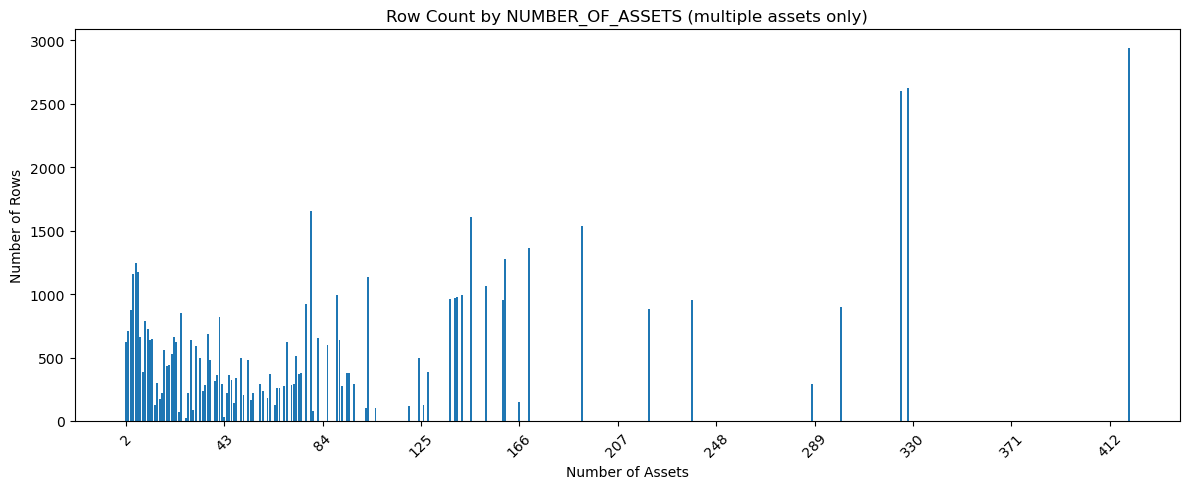

Expected total expected rows based on NUMBER_OF_ASSETS: 7312991
Actual total number of rows: 316257


In [2]:
import matplotlib.pyplot as plt

# Calculate value counts for WORK_TASK_ID
work_task_id_counts = df_tickets_assets['WORK_TASK_ID'].value_counts()

# Identify WORK_TASK_ID values that appear more than once (non-unique)
non_unique_work_task_ids = work_task_id_counts[work_task_id_counts > 1]

# Calculate the total number of rows associated with these non-unique WORK_TASK_IDs
num_rows_with_non_unique_work_task_id = non_unique_work_task_ids.sum()

print(f"Number of rows with non-unique WORK_TASK_ID values in df_tickets_assets: {num_rows_with_non_unique_work_task_id}")

# Get the list of WORK_TASK_IDs that are not unique
non_unique_work_task_ids_list = work_task_id_counts[work_task_id_counts > 1].index.tolist()

# Filter df_tickets_assets to include only rows with these non-unique WORK_TASK_IDs
df_non_unique_work_tasks = df_tickets_assets[df_tickets_assets['WORK_TASK_ID'].isin(non_unique_work_task_ids_list)]

# Count how many of these rows have 'NUMBER_OF_ASSETS' greater than 1
count_assets_less_than_2 = df_non_unique_work_tasks[df_non_unique_work_tasks['NUMBER_OF_ASSETS'] == 1].shape[0]
count_assets_equals_0 = df_non_unique_work_tasks[df_non_unique_work_tasks['NUMBER_OF_ASSETS'] == 0].shape[0]

print(f"Number of rows with non-unique WORK_TASK_ID and NUMBER_OF_ASSETS is 1: {count_assets_less_than_2}")
print(f"Number of rows with non-unique WORK_TASK_ID and NUMBER_OF_ASSETS is 0: {count_assets_equals_0}")

# Filter df_non_unique_work_tasks to find rows where NUMBER_OF_ASSETS is 0 or 1
sample_rows_zero_assets = df_non_unique_work_tasks[df_non_unique_work_tasks['NUMBER_OF_ASSETS'] == 0]
sample_rows_multiple_assets = df_non_unique_work_tasks[df_non_unique_work_tasks['NUMBER_OF_ASSETS'] > 1]


df_filtered = df_tickets_assets[df_tickets_assets['NUMBER_OF_ASSETS'] >= 2]['NUMBER_OF_ASSETS'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(df_filtered.index, df_filtered.values)

plt.xlabel('Number of Assets')
plt.ylabel('Number of Rows')
plt.title('Row Count by NUMBER_OF_ASSETS (multiple assets only)')

# Show only 10 evenly spaced labels
plt.xticks(range(df_filtered.index.min(), df_filtered.index.max(), 
           (df_filtered.index.max() - df_filtered.index.min()) // 10), rotation=45)

plt.tight_layout()
plt.show()

total_assets = df_tickets_assets['NUMBER_OF_ASSETS'].sum()
print(f"Expected total expected rows based on NUMBER_OF_ASSETS: {total_assets}")
print(f"Actual total number of rows: {df_tickets_assets.shape[0]}")


## Important Note on "Assets"

We found that the number of assets associated with each work task is not consistent with the asset data. If it was, we would expect there to be seperate rows for each asset that corresponds to the same work task ID (i.e. 2 rows for a ticket with `'NUMBER_OF_ASSETS' == 2`, 420 rows for a ticket with `'NUMBER_OF_ASSETS' == 420`). If this were the case, the merged dataframe should have had 7,312,991 rows (it only has 316,257 rows).


**This result was not very surprising to our sponsor, who noted that 'assets' are not tied consistently with tickets and work task IDs.**

## Averaged surveys from box remove too many rows!

In [3]:
# Import tools for survey data 
sys.path.append(os.path.abspath('../utils'))
from data_aggregation_tools import aggregate_surveys

df_surveys = pd.read_csv("../../data/V_OM_WORK_TASK_SURVEY.csv")

df_surveys_agg = aggregate_surveys(df_surveys)

df_surveys_agg.head()

,WORK_TASK_ID,AVERAGE_SURVEY_SCORE,WORK_TASK_NAME,WORK_TASK_STATUS,RESPONSIBLE_ORGANIZATION,RESPONSIBLE_PERSON,SERVICE_REQUEST_ID,SURVEY_SENT_DATE,SURVEY_COMMENTS,SURVEY_RESPONSE,RESPONSE_COMMENTS,SURVEY_QUESTION_DESC,BUILDING,FLOOR,REQUEST_CLASS
0,1039789,3.000000,RICE - DEFAULT - Work Task Template - Correcti...,Closed,02 Plumbing/Exterior/Mechanical,John Ramirez,SR-1000029,16:11.0,None,Meets Expectations,NaN,Communication,Bioscience Research Collaborative,02,Roof/Window Leak (Minor)
1,1039793,3.000000,RICE - DEFAULT - Work Task Template - Correcti...,Closed,04 Carpentry and Painting,David Garcia,SR-1000030,03:57.0,None,Meets Expectations,NaN,Communication,Bioscience Research Collaborative,06,Damaged Flooring/Replace
2,1039800,4.000000,RICE - DEFAULT - Work Task Template - Correcti...,Closed,11 Grounds Operations & Specialists,Gerald Contreras,SR-1000031,29:30.0,None,High Meets Expectation,NaN,Communication,Bioscience Research Collaborative,08,Heavy Trash Disposal
3,1039832,5.000000,RICE - DEFAULT - Work Task Template - Correcti...,Closed,11 Grounds Operations & Specialists,Gerald Contreras,SR-1000047,19:25.0,Thank you for your timely response.,Exceeds Expectations,NaN,Communication,Rice Stadium,02,"Pest Control - Ant, Roach, Spider"
4,1039845,2.333333,RICE - DEFAULT - Work Task Template - Correcti...,Closed,08 Elevators,John Ramirez,SR-1000057,04:03.0,I would like to know what actual customer thou...,Low Meets Expectations,Would like to see notes and comments on the wo...,Communication,Lovett Hall,03,Not Running (Unoccupied)


In [4]:
import pandas as pd

# 1. Create a new DataFrame `df_tickets_no_space` by filtering `df_tickets` to include only rows where the 'SPACE' column is null or empty
df_tickets_no_space = df_tickets[df_tickets['SPACE'].isnull() | (df_tickets['SPACE'] == '')].copy()

# 2. Print the shape of this new DataFrame
print(f"Shape of df_tickets_no_space: {df_tickets_no_space.shape}")

# 3. Calculate the distribution of these tickets by 'BUILDING' (tickets without space)
building_counts = df_tickets_no_space['BUILDING'].value_counts().reset_index()
building_counts.columns = ['BUILDING', 'Tickets Without Space']

# 4. Calculate the total number of tickets for each building from the original df_tickets
total_building_counts = df_tickets['BUILDING'].value_counts().reset_index()
total_building_counts.columns = ['BUILDING', 'Total Tickets (Original)']

# 5. Merge the two count DataFrames
building_counts_merged = pd.merge(building_counts, total_building_counts, on='BUILDING', how='left')

# Fill any NaN values in 'Total Tickets (Original)' with 0 (for buildings that might appear in no-space but not original, though unlikely here)
building_counts_merged['Total Tickets (Original)'] = building_counts_merged['Total Tickets (Original)'].fillna(0).astype(int)

# Display the merged distribution tabularly
print("\nDistribution of Tickets without Space Information by Building (with Total Original Tickets):")
display(building_counts_merged)

Shape of df_tickets_no_space: (103212, 47)

Distribution of Tickets without Space Information by Building (with Total Original Tickets):


,BUILDING,Tickets Without Space,Total Tickets (Original)
0,Tudor Fieldhouse and Youngkin Center,4482,10547
1,Facilities Engineering and Planning,3973,8365
2,Rice Stadium,3450,4381
3,Fondren Library,2743,6586
4,Bioscience Research Collaborative,2692,9804
...,...,...,...
258,South Plant Vault 8,1,1
259,Entrance 17 Road,1,1
260,Entrance 13A,1,1
261,Sunset Boulevard,1,1


### Findings for Space Attached to Tickets

For many of the tickets, there is no space attached. This will make it challenging to pinpoint if tickets correspond to the same issue — we do not have data resolution to the level of the specific place in each building where the ticket was called to, meaning that any two tickets in the same building with no space attached could be referencing a similar issue.

# Identifying Repetitive Tasks
Here, we identified corrective maintenance tasks that occur repeatedly for the same asset within a 90-day interval. We include only tasks with `WORK_TASK_STATUS == 'Completed'` and `TASK_TYPE == 'Corrective'`. To ensure the tasks refer to the same asset, we use `ASSET_ID`.

In [5]:
from data_aggregation_tools import merge_tickets_assets_surveys

df_tickets_assets_surveys = merge_tickets_assets_surveys(df_tickets_assets, df_surveys_agg, verbose=True)



Original shape of merged and filtered DataFrame: (9795, 69)
SHAPE: (9795, 69)
SHAPE after initial filter and before NaT drop: (9795, 69)
Shape of tickets/assets joined DataFrame: (316257, 55)
Shape of surveys_cleaned: (9793, 15)
Final shape of merged and filtered DataFrame: (9795, 69)
Columns in merged and filtered DataFrame: ['WORK_TASK_ID', 'WORK_TASK_NAME_ticket', 'WORK_TASK_STATUS_ticket', 'RICE_WORK_STATUS', 'ASSIGNMENT_STATUS', 'DESCRIPTION', 'TASK_TYPE', 'TASK_PRIORITY', 'REQUEST_CLASS_x', 'SERVICE_CLASS', 'PRIMARY_LOCATION', 'PROPERTY', 'BUILDING_x', 'FLOOR_x', 'SPACE', 'GEOGRAPHY_LOOKUP', 'CUSTOMER_ORGANIZATION', 'CUSTOMER_COMPANY', 'CUSTOMER_DIVISION', 'CUSTOMER_DEPARTMENT', 'RESPONSIBLE_ORGANIZATION_NAME', 'ORGANIZATION_TYPE', 'RESPONSIBLE_ORGANIZATION_PATH', 'RESPONSIBLE_PERSON_NAME', 'RESPONSIBLE_PERSON_EMAIL', 'RESPONSIBLE_PERSON_WORKPHONE', 'BASELINE_START_LTZ', 'BASELINE_END_LTZ', 'ASSIGNED_DATE_LTZ', 'PLANNED_START_LTZ', 'PLANNED_END_LTZ', 'PLANNED_FOLLOW_UP_DATE_LTZ',

Let's ensure that the survey data only contains tickets that appear in the work task/asset dataset.

In [6]:
# Get unique WORK_TASK_IDs from df_surveys_avg
work_task_ids_in_surveys_agg = set(df_surveys_agg['WORK_TASK_ID'].unique())

# Get unique WORK_TASK_IDs from df_tickets_assets
work_task_ids_in_tickets_assets = set(df_tickets_assets['WORK_TASK_ID'].unique())

# Find WORK_TASK_IDs that are in df_surveys_avg but NOT in df_tickets_assets
ids_only_in_surveys_agg = list(work_task_ids_in_surveys_agg - work_task_ids_in_tickets_assets)

print(f"Number of unique WORK_TASK_IDs in aggregated surveys: {len(work_task_ids_in_surveys_agg)}")
print(f"WORK_TASK_IDs found in aggregated surveys but NOT in aggregated tickets/assets: {ids_only_in_surveys_agg}")
print(f"Number of WORK_TASK_IDs found: {len(ids_only_in_surveys_agg)}")

if not ids_only_in_surveys_agg:
    print("As expected, all WORK_TASK_IDs from df_surveys_avg are present in df_tickets_assets.")
else:
    print("There was an unexpected mismatch in WORK_TASK_IDs.")

Number of unique WORK_TASK_IDs in aggregated surveys: 9793
WORK_TASK_IDs found in aggregated surveys but NOT in aggregated tickets/assets: []
Number of WORK_TASK_IDs found: 0
As expected, all WORK_TASK_IDs from df_surveys_avg are present in df_tickets_assets.


In [7]:
print("Most frequent WORK_TASK_ID entries and their counts:")
display(df_surveys['WORK_TASK_ID'].value_counts())

Most frequent WORK_TASK_ID entries and their counts:


WORK_TASK_ID
1216895    9
1162455    9
1161067    9
1161063    9
1162487    9
          ..
1264715    1
1256255    1
1310434    1
1044214    1
1042908    1
Name: count, Length: 9793, dtype: int64

In [8]:
# Get the WORK_TASK_IDs from the most frequent entries in df_surveys
most_frequent_work_task_ids = df_surveys['WORK_TASK_ID'].value_counts().index.tolist()

print(f"most_frequent_work_task_ids: {most_frequent_work_task_ids}")
print(f"most_frequent_work_task_ids length: {len(most_frequent_work_task_ids)}")


# Filter df_tickets_assets_surveys for these WORK_TASK_IDs
matching_rows = df_tickets_assets_surveys[df_tickets_assets_surveys['WORK_TASK_ID'].isin(most_frequent_work_task_ids)]

print(f"\n matching_rows: {matching_rows}")

print(f"Found {len(matching_rows)} rows in df_tickets_assets_surveys matching the most frequent WORK_TASK_IDs from df_surveys.")
display(matching_rows.head()) # Display the first few matching rows

most_frequent_work_task_ids: [1216895, 1162455, 1161067, 1161063, 1162487, 1162486, 1162464, 1162462, 1162461, 1162460, 1162458, 1160895, 1162411, 1160892, 1162477, 1162476, 1162496, 1162494, 1162493, 1161639, 1161627, 1161623, 1161071, 1161075, 1161079, 1162478, 1214388, 1218044, 1218041, 1218039, 1218038, 1218037, 1218034, 1218031, 1218024, 1218021, 1218026, 1218029, 1218019, 1218016, 1218014, 1217601, 1217595, 1217576, 1217572, 1161619, 1161615, 1161611, 1162334, 1162328, 1162322, 1160014, 1159990, 1159971, 1159968, 1159910, 1162320, 1160686, 1162324, 1162321, 1162315, 1162312, 1162309, 1162303, 1162294, 1162363, 1162360, 1162357, 1162331, 1162337, 1161607, 1162340, 1162413, 1162404, 1162401, 1162398, 1162395, 1162392, 1162389, 1162383, 1162380, 1162374, 1162368, 1162365, 1162362, 1162359, 1162356, 1162353, 1162350, 1162346, 1162344, 1214393, 1214414, 1214394, 1216925, 1216213, 1216214, 1216933, 1216932, 1216930, 1216929, 1216928, 1216926, 1216945, 1216944, 1216962, 1216960, 1216959

,WORK_TASK_ID,WORK_TASK_NAME_ticket,WORK_TASK_STATUS_ticket,RICE_WORK_STATUS,ASSIGNMENT_STATUS,DESCRIPTION,TASK_TYPE,TASK_PRIORITY,REQUEST_CLASS_x,SERVICE_CLASS,...,RESPONSIBLE_PERSON,SERVICE_REQUEST_ID,SURVEY_SENT_DATE,SURVEY_COMMENTS,SURVEY_RESPONSE,RESPONSE_COMMENTS,SURVEY_QUESTION_DESC,BUILDING_y,FLOOR_y,REQUEST_CLASS_y
0,1302412,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,In need of bed lofted up to second bunk level,Corrective,R2 - Routine,Loft Bed,Building Interior,...,Morris Knight,SR-1084645,12:14.0,Carl was amazing and extremely helpful,Exceeds Expectations,NaN,Communication,Duncan College,04,Loft Bed
1,1302432,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,Contact Connie Miller cell (281) 202-7568 to m...,Corrective,3 - Routine,Other Carpentry,Carpentry,...,David Garcia,SR-1084664,51:34.0,The crew showed their resourcefulness while ha...,High Meets Expectation,NaN,Communication,Sewall Hall,02,Other Carpentry
2,1302470,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,Toilet wouldn't flush after several tries,Corrective,2 - Urgent,Toilet/Urinal,Plumbing,...,Morris Knight,SR-1084702,36:07.0,None,Exceeds Expectations,NaN,Communication,Duncan College,02,Toilet/Urinal
3,1302486,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,The air quality is quite low. My roommate brou...,Corrective,2 - Urgent,Air Quality/Air Flow Issues,HVAC,...,Morris Knight,SR-1084718,37:08.0,None,High Meets Expectation,NaN,Communication,Martel College,04,Air Quality/Air Flow Issues
4,1239631,RICE - DEFAULT - Work Task Template - Correcti...,Closed,Work Done,Completed,Ceiling partially collapsed in Hall A near HRZ...,Corrective,3 - Routine,Damaged Ceiling Tiles,Carpentry,...,David Garcia,SR-1047082,33:23.0,None,Meets Expectations,"Done quickly, after prodding to start. Repair ...",Communication,Herzstein Hall,02,Damaged Ceiling Tiles


## Most tickets do not have corresponding surveys that are recorded.

*See analysis below.*

Number of unique WORK_TASK_IDs in df_tickets_assets: 227201
Number of unique WORK_TASK_IDs in df_surveys_agg: 9793
Number of unique WORK_TASK_IDs in df_tickets_assets but not in df_surveys_agg: 217408


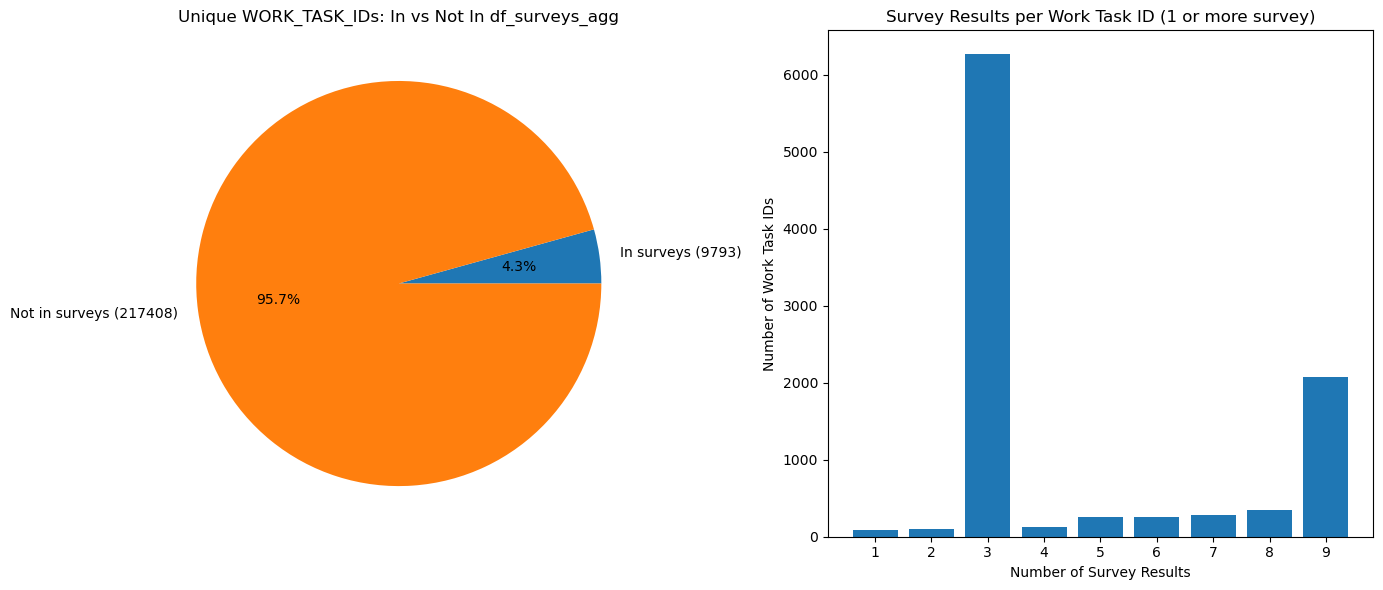

In [26]:
import pandas as pd

# Get unique WORK_TASK_IDs from df_tickets_assets
tickets_assets_ids = set(df_tickets_assets['WORK_TASK_ID'].unique())

# Get unique WORK_TASK_IDs from df_surveys_avg
surveys_agg_ids = set(df_surveys_agg['WORK_TASK_ID'].unique())

# Find WORK_TASK_IDs in df_tickets_assets that are not in df_surveys_avg
ids_only_in_tickets_assets = list(tickets_assets_ids - surveys_agg_ids)

# Filter df_tickets_assets to get rows with these IDs
df_tickets_assets_not_in_surveys = df_tickets_assets[df_tickets_assets['WORK_TASK_ID'].isin(ids_only_in_tickets_assets)]

print(f"Number of unique WORK_TASK_IDs in df_tickets_assets: {len(tickets_assets_ids)}")
print(f"Number of unique WORK_TASK_IDs in df_surveys_agg: {len(surveys_agg_ids)}")
print(f"Number of unique WORK_TASK_IDs in df_tickets_assets but not in df_surveys_agg: {len(ids_only_in_tickets_assets)}")


# Get the WORK_TASK_IDs from the most frequent entries in df_surveys
most_frequent_work_task_ids = df_surveys['WORK_TASK_ID'].value_counts().index.tolist()

# Filter df_tickets_assets_surveys for these WORK_TASK_IDs
matching_rows = df_tickets_assets_surveys[df_tickets_assets_surveys['WORK_TASK_ID'].isin(most_frequent_work_task_ids)]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# -===-
# Plots
# -===-
in_surveys = len(tickets_assets_ids & surveys_agg_ids)
not_in_surveys = len(ids_only_in_tickets_assets)

ax1.pie(
    [in_surveys, not_in_surveys],
    labels=[f'In surveys ({in_surveys})', f'Not in surveys ({not_in_surveys})'],
    autopct='%1.1f%%'
)
ax1.set_title('Unique WORK_TASK_IDs: In vs Not In df_surveys_agg')

# Bar chart
survey_counts = df_surveys['WORK_TASK_ID'].value_counts()
survey_counts_filtered = survey_counts[(survey_counts >= 1) & (survey_counts <= 9)]
binned = survey_counts_filtered.value_counts().sort_index()

ax2.bar(binned.index, binned.values)
ax2.set_xlabel('Number of Survey Results')
ax2.set_ylabel('Number of Work Task IDs')
ax2.set_title('Survey Results per Work Task ID (1 or more survey)')
ax2.set_xticks(range(1, 10))

plt.tight_layout()
plt.show()


### Important note about survey data

**The plots above show that:**
1. Most tickets **do not** have surveys attached
2. Tickets with surveys attached *typically* have 3 or 9 survey entries (describing unique user input to survey questions)

In [13]:
asset_recurrence_counts = df_tickets_filtered_by_asset['ASSET_NAME'].value_counts()

print("Recurrence counts of ASSET_NAME calculated:")
print(asset_recurrence_counts.head())

Recurrence counts of ASSET_NAME calculated:
ASSET_NAME
VAN-FEP-04    1
Name: count, dtype: int64


# Explore Assets with More than 1 Repetitive Task

Here, we will do some data exploration on the assets that are repeatedly being fixed.

In [15]:
import pandas as pd

# Get a list of ASSET_IDs that have more than one repetitive task
# This means they are actually contributing to the 'repetitive_tasks_by_asset_list'
repetitive_asset_ids = df_tickets_filtered_by_asset['ASSET_ID'].value_counts()
repetitive_asset_ids = repetitive_asset_ids[repetitive_asset_ids > 1].index.tolist()

print(f"Found {len(repetitive_asset_ids)} assets with more than one repetitive task.")

if not repetitive_asset_ids:
    print("No assets found with more than one repetitive task to analyze further.")
else:
    # Select a few assets for detailed inspection (e.g., the first 3)
    assets_to_inspect = repetitive_asset_ids[:3]

    for asset_id in assets_to_inspect:
        print(f"\n--- Analyzing ASSET_ID: {asset_id} ---")

        # Get all tasks for this specific asset from the originally filtered data (df_merged_assets)
        # not just the ones deemed 'repetitive' by the previous 90-day filter
        asset_tasks = df_merged_assets[df_merged_assets['ASSET_ID'] == asset_id].copy()

        # Sort these tasks by time
        asset_tasks_sorted = asset_tasks.sort_values(by='BASELINE_START_LTZ').reset_index(drop=True)

        if len(asset_tasks_sorted) < 2:
            print("  Not enough tasks for this asset to calculate time differences.")
            continue

        print(f"  Number of tasks for this asset: {len(asset_tasks_sorted)}")

        # Calculate time differences between consecutive tasks
        time_differences = asset_tasks_sorted['BASELINE_START_LTZ'].diff().dropna()

        if not time_differences.empty:
            print("  Consecutive task time differences:")
            for diff in time_differences:
                print(f"    - {diff}")
        else:
            print("  No consecutive time differences found.")

    print("\nThis analysis should help understand if the repetitions are indeed very close in time across the dataset.")

Found 0 assets with more than one repetitive task.
No assets found with more than one repetitive task to analyze further.


# ---------------------------------------
# EVERYTHING BELOW THIS POINT IS OUTDATED.
# ---------------------------------------

## [OLD] Find Repetitive Tasks

Here, I create a list of the tickets that are "repetitive". Two tasks are defined as repetitive if:

1. The tasks are both Corrective (`TASK_TYPE == "Corrective"`)
2. The tasks have both been completed (`TASK_WORK_STATUS == "Completed"`)
3. The two tasks share the same location (`PRIMARY_LOCATION` is the same)

In [16]:
import pandas as pd

# Filter tasks based on the new pseudocode requirement
df_tickets_filtered = df_tickets[(df_tickets['WORK_TASK_STATUS'] == 'Completed') & (df_tickets['TASK_TYPE'] == 'Corrective')].copy()

# Ensure 'BASELINE_START_LTZ' is in datetime format
# Using errors='coerce' to handle any unparseable dates by turning them into NaT (Not a Time)
if not pd.api.types.is_datetime64_any_dtype(df_tickets_filtered['BASELINE_START_LTZ']):
    df_tickets_filtered['BASELINE_START_LTZ'] = pd.to_datetime(df_tickets_filtered['BASELINE_START_LTZ'], errors='coerce')

# Drop rows where 'BASELINE_START_LTZ' couldn't be parsed, as they can't be used for date comparisons
df_tickets_filtered.dropna(subset=['BASELINE_START_LTZ'], inplace=True);

# Sort the DataFrame by 'BASELINE_START_LTZ' to efficiently check for subsequent tasks within a time window
df_tickets_sorted = df_tickets_filtered.sort_values(by='BASELINE_START_LTZ').reset_index(drop=True)

repeated_tasks_lst = []
ninety_days = pd.Timedelta(days=90)
n_tasks = len(df_tickets_sorted)

for idx in range(n_tasks):
    # Get the BASELINE_START_LTZ for the current task
    current_task_time = df_tickets_sorted.loc[idx, 'BASELINE_START_LTZ']

    # Iterate through subsequent tasks starting from the next one (idx + 1)
    # jdx_offset is used as the 'jdx' from the pseudocode, representing the offset from 'idx'
    for jdx_offset in range(1, n_tasks - idx):
        subsequent_task_index = idx + jdx_offset

        # Get the BASELINE_START_LTZ for the subsequent task
        other_task_time = df_tickets_sorted.loc[subsequent_task_index, 'BASELINE_START_LTZ']

        # Calculate the time difference
        time_difference = other_task_time - current_task_time

        # If the difference is within 90 days, a repeated task is found for the current 'idx' task
        if time_difference <= ninety_days:
            # Add the current task (df_tickets_sorted.loc[idx]) to the list
            # .to_dict() converts the Series (row) to a dictionary for list storage
            repeated_tasks_lst.append(df_tickets_sorted.loc[idx].to_dict())
            break # Break from the inner loop as a repetition is found for the current task
        elif time_difference > ninety_days:
            # Since the DataFrame is sorted by time, if the current subsequent task is already
            # beyond 90 days, all further tasks will also be, so we can break early.
            break # Optimization: break from inner loop

# You can now work with repeated_tasks_lst, e.g., convert it to a DataFrame:
repeated_tasks_df = pd.DataFrame(repeated_tasks_lst)

print("Found repeated tasks based on 90-day window.")
# print(repeated_tasks_df.head())

print(f"Number of repeated tasks in dataset: {repeated_tasks_df.shape[0]}")

Found repeated tasks based on 90-day window.
Number of repeated tasks in dataset: 37170


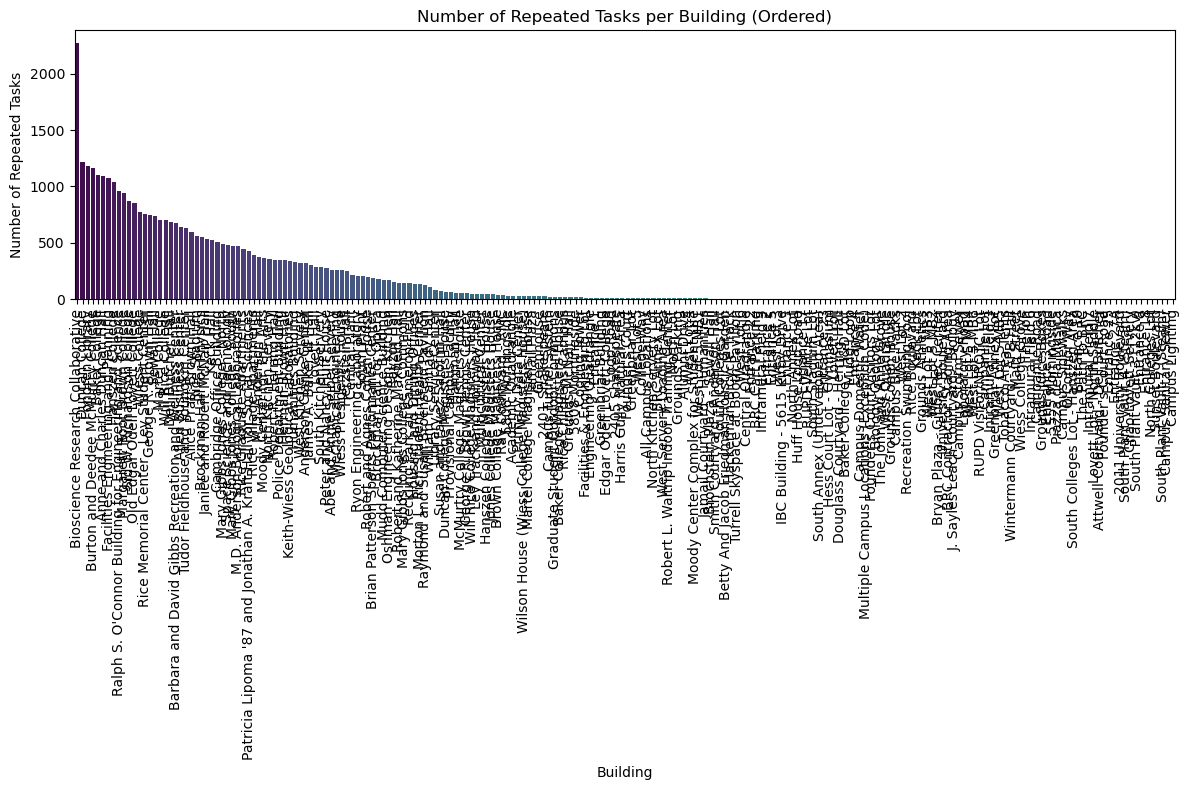

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of instances for each unique 'BUILDING'
building_counts = repeated_tasks_df['BUILDING'].value_counts().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x=building_counts.index, y=building_counts.values, palette='viridis')

plt.title('Number of Repeated Tasks per Building (Ordered)')
plt.xlabel('Building')
plt.ylabel('Number of Repeated Tasks')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## [OLD] This bar chart is hard to read, so let's create an **interactive html page** with the data.


You can find this html file in `/content/sample_data/repeated_tasks_per_building_interactive.html`.

In [18]:
import plotly.express as px
import pandas as pd

# Create a temporary DataFrame with explicit column names for Plotly
df_plot = pd.DataFrame({
    'Building': building_counts.index,
    'Repeated Tasks': building_counts.values
})

# Create an interactive bar chart using Plotly Express
fig = px.bar(
    df_plot, # Pass the DataFrame
    x='Building',
    y='Repeated Tasks',
    title='Number of Repeated Tasks per Building (Interactive)',
    color='Repeated Tasks', # Use the column name for color, which will appear in hover
    color_continuous_scale=px.colors.sequential.Viridis,
    labels={'Building': 'Building', 'Repeated Tasks': 'Number of Repeated Tasks'} # Labels for axis titles
)

# Update layout for better readability, especially with many items
fig.update_layout(
    xaxis_tickangle=-90, # Rotate x-axis labels
    xaxis_title_standoff=25, # Add some space below the x-axis title
    height=700 # Increase chart height for better visibility
)

# Save the interactive chart as an HTML file
output_filename = 'repeated_tasks_per_building_interactive.html'
fig.write_html(output_filename)

print(f"Interactive chart saved as '{output_filename}'")

Interactive chart saved as 'repeated_tasks_per_building_interactive.html'


In [19]:
# Filter df_tickets for 'Duncan College' in 'BUILDING'
duncan_college_tasks = df_tickets[df_tickets['BUILDING'] == 'Duncan College'].copy()

# Save the filtered tasks to a CSV file
output_csv_filename = 'duncan_college_tasks_only.csv'
duncan_college_tasks.to_csv(output_csv_filename, index=False)

print(f"Filtered tasks saved to '{output_csv_filename}'")
print(f"Number of tasks found: {len(duncan_college_tasks)}")

Filtered tasks saved to 'duncan_college_tasks_only.csv'
Number of tasks found: 2625


In [20]:
import pandas as pd
import re # Import the regular expression module

def find_rows_with_keywords(dataframe, keywords):
    """
    Finds rows in a DataFrame where the 'DESCRIPTION' column contains any of the specified keywords.
    Keywords must match as whole words.

    Args:
        dataframe (pd.DataFrame): The input DataFrame (e.g., df_tickets).
        keywords (list): A list of strings to search for in the 'DESCRIPTION' column.

    Returns:
        list: A list of dictionaries, where each dictionary represents a row
              that contains any of the keywords in its 'DESCRIPTION' column.
    """
    if 'DESCRIPTION' not in dataframe.columns:
        print("Error: 'DESCRIPTION' column not found in the DataFrame.")
        return []

    # Ensure 'DESCRIPTION' column is string type and handle NaNs
    # Operate on a copy to avoid modifying the original df_tickets directly
    temp_description_series = dataframe['DESCRIPTION'].astype(str).fillna('')

    matching_rows_list = []

    for index, row in dataframe.iterrows():
        description = temp_description_series.loc[index].lower() # Use the cleaned description
        for keyword in keywords:
            # Use regex with word boundaries (\b) for whole word match
            # re.escape() is used to escape any special characters in the keyword
            if re.search(r'\b' + re.escape(keyword.lower()) + r'\b', description):
                matching_rows_list.append(row.to_dict())
                break  # Stop checking keywords for this row once a match is found
    return matching_rows_list

# Example usage:

search_keywords = ["toilet"]

# Find rows matching any of the keywords
matching_tickets = find_rows_with_keywords(df_tickets, search_keywords)

print(f"Found {len(matching_tickets)} tickets containing any of the keywords: {search_keywords}")

if matching_tickets:
    print("First 5 matching tickets (as dictionaries):")
    for i, ticket in enumerate(matching_tickets[:5]):
        print(f"Ticket {i+1}: {ticket['WORK_TASK_NAME']}")
        print(f"Description: {ticket['DESCRIPTION'][:100]}...") # Print first 100 chars of description
else:
    print("No matching tickets found.")

# Convert the list of dictionaries to a DataFrame
df_matching_tickets = pd.DataFrame(matching_tickets)

# Check if the DataFrame is empty before saving to CSV
if not df_matching_tickets.empty:
    # Save the DataFrame to a CSV file
    output_csv_filename = 'matching_tickets.csv'
    df_matching_tickets.to_csv(output_csv_filename, index=False)

    print(f"The matching tickets have been saved to '{output_csv_filename}'")
else:
    print("No matching tickets were found for the given keywords. The CSV file will not be created as it would be empty.")
    print("Please consider using different keywords that might be present in the 'DESCRIPTION' column.")

Found 2977 tickets containing any of the keywords: ['toilet']
First 5 matching tickets (as dictionaries):
Ticket 1: RICE - DEFAULT - Work Task Template - Corrective Maintenance-Toilet/Urinal
Description: Toilet doesn’t flush again :,) ...
Ticket 2: RICE - DEFAULT - Work Task Template - Corrective Maintenance-Toilet/Urinal
Description: Old Baker Women's Restroom Stair F across from Room 334, the first toilet, the water is running and ...
Ticket 3: RICE - DEFAULT - Work Task Template - Corrective Maintenance-Other Mechanical Repair
Description: The wall of the toilet fell off/is loose....
Ticket 4: RICE - DEFAULT - Work Task Template - Corrective Maintenance-Toilet/Urinal
Description: Toilet wouldn't flush after several tries...
Ticket 5: RICE - DEFAULT - Work Task Template - Corrective Maintenance-Repair Furniture
Description: Broken toilet seat...
The matching tickets have been saved to 'matching_tickets.csv'


# Outlier Detection Strategy for Repetitive Tickets

To detect "outlier" tickets—specifically those indicating an asset is constantly failing despite repairs—we can move beyond simple rule-based filters (like the 90-day logic) to a statistical or machine learning-based approach. Here is the high-level plan:

## 1. Feature Engineering (Creating the Data)
We need to aggregate data at the **Asset** or **Location** level. The model will judge *assets*, not individual tickets, to see if their failure behavior is anomalous.

Key features to calculate for each asset:
*   **Recurrence Count**: Number of corrective tickets in the last X days.
*   **Mean Time Between Failures (MTBF)**: Average days between consecutive tickets. (Lower is worse).
*   **Total Cost/Effort**: Sum of `ACTUAL_COST` or `ACTUAL_HOURS`.
*   **Description Similarity**: (Advanced) How similar are the descriptions? If they are 100% similar, it's definitely the same issue.

## 2. Model Selection
Since we don't have a labeled dataset saying "this asset is definitely broken" (unsupervised learning), we can use:

*   **Isolation Forest**: An algorithm specifically designed to detect anomalies. It works by isolating observations; anomalies are easier to isolate (fewer splits) than normal points. It's effective for high-dimensional data (e.g., combining Frequency + Cost + MTBF).
*   **DBSCAN (Density-Based Clustering)**: Groups "normal" assets together and marks points in low-density regions as outliers.
*   **Statistical Thresholds (Z-Score / IQR)**: Simple but effective. Any asset with a recurrence count > 3 standard deviations from the mean is an outlier.

## 3. Implementation Plan
1.  **Aggregate**: Group `df_tickets` (or the merged asset dataframe) by `ASSET_ID`.
2.  **Calculate Features**: Compute `Ticket_Count`, `Avg_Days_Diff`, `Total_Cost` for each asset.
3.  **Train Model**: Feed these features into an **Isolation Forest**.
4.  **Evaluate**: The model will assign an "anomaly score". Assets with high scores are the ones getting repaired suspiciously often.

We can start by building the dataset for the model.

In [21]:
import pandas as pd
import numpy as np

# --- 1. Prepare the Data ---
# We use the previously created df_merged_assets which contains Corrective, Completed tickets with Asset IDs.

# Ensure dates are in datetime format
df_merged_assets['BASELINE_START_LTZ'] = pd.to_datetime(df_merged_assets['BASELINE_START_LTZ'])

# Sort by Asset and Date to calculate intervals correctly
df_sorted = df_merged_assets.sort_values(by=['ASSET_ID', 'BASELINE_START_LTZ'])

# --- 2. Feature Engineering per Asset ---
# We need to calculate metrics for each asset to feed into the model.

asset_features_list = []

for asset_id, group in df_sorted.groupby('ASSET_ID'):
    # We need at least 2 tickets to calculate an interval (time between failures)
    if len(group) < 2:
        continue

    # Calculate time differences between consecutive tickets
    time_diffs = group['BASELINE_START_LTZ'].diff().dropna()

    # Convert time differences to days
    days_between_failures = time_diffs.dt.total_seconds() / (60 * 60 * 24)

    if len(days_between_failures) == 0:
         continue

    feature_dict = {
        'ASSET_ID': asset_id,
        'ASSET_NAME': group['ASSET_NAME'].iloc[0], # Grab the name for reference
        'Ticket_Count': len(group),
        'Avg_Days_Between_Failures': days_between_failures.mean(),
        'Min_Days_Between_Failures': days_between_failures.min(),
        'Std_Dev_Days': days_between_failures.std(ddof=0) # Standard deviation of intervals
    }
    asset_features_list.append(feature_dict)

# Create the Features DataFrame
df_features = pd.DataFrame(asset_features_list)

# Fill NaN values (e.g., if Std_Dev is NaN for some reason)
df_features.fillna(0, inplace=True)

print(f"Feature dataset created with {len(df_features)} assets.")
display(df_features.head())

NameError: name 'df_merged_assets' is not defined

In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3. Initialize and Train Isolation Forest ---
# contamination: The expected proportion of outliers in the data set.
# We estimate that about 5% of these assets are truly anomalous 'lemons'.
model = IsolationForest(contamination=0.05, random_state=42)

# Select features for the model
features_to_use = ['Ticket_Count', 'Avg_Days_Between_Failures']

# Fit the model
model.fit(df_features[features_to_use])

# --- 4. Predict Anomalies ---
# The model returns -1 for outliers and 1 for inliers (normal)
df_features['anomaly_label'] = model.predict(df_features[features_to_use])

# Calculate Anomaly Score (Lower scores mean more anomalous)
df_features['anomaly_score'] = model.decision_function(df_features[features_to_use])

# Separate outliers for inspection
outliers = df_features[df_features['anomaly_label'] == -1].sort_values(by='anomaly_score')

print(f"Identified {len(outliers)} outliers out of {len(df_features)} assets.")

print("\n--- Top 10 Anomalous Assets (High frequency, low interval) ---")
display(outliers[['ASSET_ID', 'ASSET_NAME', 'Ticket_Count', 'Avg_Days_Between_Failures', 'anomaly_score']].head(10))

# --- 5. Visualize the Results ---
plt.figure(figsize=(12, 8))

# Plot normal points
plt.scatter(df_features[df_features['anomaly_label'] == 1]['Avg_Days_Between_Failures'],
            df_features[df_features['anomaly_label'] == 1]['Ticket_Count'],
            c='blue', label='Normal Asset', alpha=0.5)

# Plot outliers
plt.scatter(outliers['Avg_Days_Between_Failures'],
            outliers['Ticket_Count'],
            c='red', label='Outlier Asset', edgecolor='k', s=100)

plt.title('Isolation Forest Outlier Detection: Asset Failures')
plt.xlabel('Average Days Between Failures (Lower is worse)')
plt.ylabel('Total Ticket Count (Higher is worse)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

NameError: name 'df_features' is not defined